# Import Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
import sympy as smp

# Solving Lagrange's Equations

# Solve Lagranges Equation 

In [2]:
x, g, m, rho, c, lm = smp.symbols(r"x g m \rho c \lambda", real=True)
y, l = smp.symbols("y l", cls=smp.Function)
y = y(x)
l = l(x)

y_d = smp.diff(y)
y_dd = smp.diff(y_d)

l_d = smp.diff(l)
l_dd = smp.diff(l_d)

In [3]:
L = rho * g * y * smp.sqrt(1 + y_d**2)
L

\rho*g*sqrt(Derivative(y(x), x)**2 + 1)*y(x)

In [4]:
h = y_d * smp.diff(L, y_d) - L
h

-\rho*g*sqrt(Derivative(y(x), x)**2 + 1)*y(x) + \rho*g*y(x)*Derivative(y(x), x)**2/sqrt(Derivative(y(x), x)**2 + 1)

In [5]:
dydx = smp.solve(smp.Eq(h, lm), y_d)[1]
dydx

sqrt(-1 + \rho**2*g**2*y(x)**2/\lambda**2)

In [6]:
dx = 1/dydx

dx.subs({y: x}).integrate(x).subs({x: y}) + c

c + Piecewise((y(x)*Abs(\lambda)*acosh(Abs(\rho)*Abs(g)*Abs(y(x))/Abs(\lambda))/(Abs(\rho)*Abs(g)*Abs(y(x))) - I*pi*y(x)*Abs(\lambda)/(2*Abs(\rho)*Abs(g)*Abs(y(x))), \rho**2*g**2*y(x)**2/\lambda**2 > 1), (-I*y(x)*Abs(\lambda)*asin(Abs(\rho)*Abs(g)*Abs(y(x))/Abs(\lambda))/(Abs(\rho)*Abs(g)*Abs(y(x))), True))

In [7]:
y_eq = smp.solve(smp.Eq(lm * smp.acosh(rho * g * y / lm) / (rho * g) + c, x), y)[0]
y_eq

\lambda*cosh(\rho*g*(c - x)/\lambda)/(\rho*g)

# Finding $\lambda$ and $c$

In [8]:
y_f = smp.lambdify((x, rho, g, lm, c), y_eq)

In [9]:
x1 = 0
y1 = 0
x2 = 1
y2 = 1
l = 10
m = 1

In [10]:
l_eq = smp.sqrt(1 + smp.diff(y_eq, x)**2)
l_eq

sqrt(sinh(\rho*g*(c - x)/\lambda)**2 + 1)

In [11]:
l_eq = smp.cosh(rho * g * (c - x) / lm) * lm / (rho * g)
l_eq

\lambda*cosh(\rho*g*(c - x)/\lambda)/(\rho*g)

In [12]:
l_eq = smp.integrate(l_eq, (x, x1, x2))
l_eq

\lambda**2*sinh(\rho*c*g/\lambda)/(\rho**2*g**2) + \lambda**2*sinh(\rho*g*(1 - c)/\lambda)/(\rho**2*g**2)

In [13]:
system = smp.Matrix(
    [
        (y_eq - y).subs({x: x1, y: y1, rho: m / l, g: 9.8}),
        (y_eq - y).subs({x: x2, y: y2, rho: m / l, g: 9.8}),
        # (l_eq - l).subs({rho: m / l, g: 9.8}),
    ],
)
system

Matrix([
[          1.02040816326531*\lambda*cosh(0.98*c/\lambda)],
[1.02040816326531*\lambda*cosh(0.98*(c - 1)/\lambda) - 1]])

In [14]:
obj_f = smp.lambdify(
    (lm, c),
    system,
    modules="numpy",
)

def objective(v):
    return obj_f(*v).reshape(2)

In [15]:
jac_f = smp.lambdify(
    (lm, c),
    system.jacobian(smp.Matrix([lm, c])),
    modules="numpy",
)

def jac(v):
    return jac_f(*v)

In [16]:

root = opt.root(objective, [0.5, 0.5], jac=jac, method="hybr")

In [17]:
[ll, cc] = root.x

# Plotting the catenary

In [18]:
y_f(0, m/l, 9.8, ll, cc)

np.float64(0.522819145804748)

In [19]:
xs = np.linspace(x1, x2, 1000)
ys = np.array([y_f(xs, m/l, 9.8, ll, cc) for xs in xs])

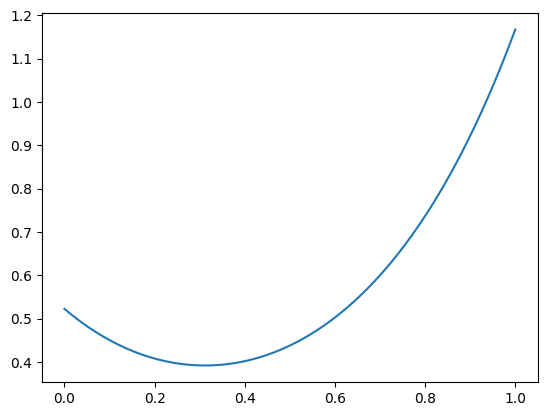

In [20]:
plt.plot(xs, ys)